# 2.6 — POI Data Visualization

Visual exploration of the **Points-of-Interest (POI)** features built by
`01_03_Fetch_POI_Data` for the demand pipeline's spatial units (community areas and
H3 res 6 / 7). POI features are *static per cell* — they describe **what kind of place**
a cell is, which is useful context for the descriptive spatial analysis ("why is demand
high here?").

**Contents**
1. Citywide POI counts overview
2. Feature distributions (histograms)
3. Choropleth maps — community areas
4. H3 maps & resolution comparison
5. Correlations among POI features
6. Top community areas by feature
7. POI vs taxi demand (does the context explain demand?)

### Data Requirements
1. `data/poi/poi_features_community_area.parquet` — produced by `01_03_Fetch_POI_Data`
2. `data/poi/poi_features_h3.parquet` — produced by `01_03_Fetch_POI_Data`
3. `data/geometry/Boundaries_Community_Areas_20260608.geojson`
4. `data/aggregated/community_area/demand_ca_24h.parquet` (section 7 only) — from `01_07_Data_Aggregation`


## Setup

In [1]:
import os
from pathlib import Path
import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/hendrik/Coding/Master/AAA


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import h3
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

In [3]:
# --- Load POI features + community-area geometry ---
poi_ca = pd.read_parquet("data/poi/poi_features_community_area.parquet")
poi_h3 = pd.read_parquet("data/poi/poi_features_h3.parquet")

community_areas = gpd.read_file("data/geometry/Boundaries_Community_Areas_20260608.geojson").to_crs(4326)
community_areas["community_area"] = community_areas["area_numbe"].astype(int)
community_areas = community_areas[["community_area", "community", "geometry"]]
CITY = community_areas.dissolve().geometry.boundary  # city outline

# CA features + geometry + names, ready for choropleths
ca = community_areas.merge(poi_ca, on="community_area")

# feature groups
DIST_FEATURES = ["dist_to_nearest_airport_km", "dist_to_nearest_train_station_km",
                 "dist_to_nearest_stadium_km"]
DENS_FEATURES = ["restaurants_per_km2", "bars_and_clubs_per_km2", "hotels_per_km2",
                 "hospitals_per_km2", "universities_per_km2", "train_station_per_km2",
                 "attractions_per_km2"]
COUNT_FEATURES = [c for c in poi_ca.columns if c.startswith("count_")]
TOTAL = "poi_density_total_per_km2"

print(f"community areas : {len(poi_ca)}  ({poi_ca.shape[1]} feature cols)")
print(f"H3 cells        : {dict(poi_h3.groupby('resolution').size())}")
poi_ca.describe().round(2)

community areas : 77  (20 feature cols)
H3 cells        : {'low': np.int64(44), 'medium': np.int64(193)}


,community_area,area_km2,dist_to_nearest_airport_km,dist_to_nearest_train_station_km,count_train_station,train_station_per_km2,dist_to_nearest_stadium_km,count_restaurants,restaurants_per_km2,count_bars_and_clubs,bars_and_clubs_per_km2,count_hotels,hotels_per_km2,count_hospitals,hospitals_per_km2,count_universities,universities_per_km2,count_attractions,attractions_per_km2,poi_density_total_per_km2
count,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00,77.00
mean,39.00,7.77,11.95,1.00,2.65,0.42,3.04,30.74,4.47,12.45,1.72,2.36,0.39,0.55,0.07,0.82,0.13,2.69,0.41,7.62
std,22.37,5.10,4.58,0.79,3.29,0.62,1.70,58.52,8.38,24.37,3.21,10.94,1.88,0.94,0.12,1.94,0.34,7.53,1.17,14.62
min,1.00,1.57,1.06,0.11,0.00,0.00,0.28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,20.00,4.62,9.25,0.42,1.00,0.09,1.79,3.00,0.35,1.00,0.16,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.08
50%,39.00,7.40,12.36,0.71,2.00,0.34,2.88,7.00,1.09,3.00,0.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.96
75%,58.00,9.18,15.33,1.34,4.00,0.60,4.24,29.00,4.62,9.00,1.49,1.00,0.08,1.00,0.12,1.00,0.13,2.00,0.24,6.83
max,77.00,34.54,20.78,3.56,22.00,5.11,7.50,312.00,44.83,122.00,17.13,80.00,12.31,5.00,0.66,10.00,2.32,48.00,6.74,83.86


## 1 — Citywide POI counts

How many of each POI type the city contains (summed over community areas).

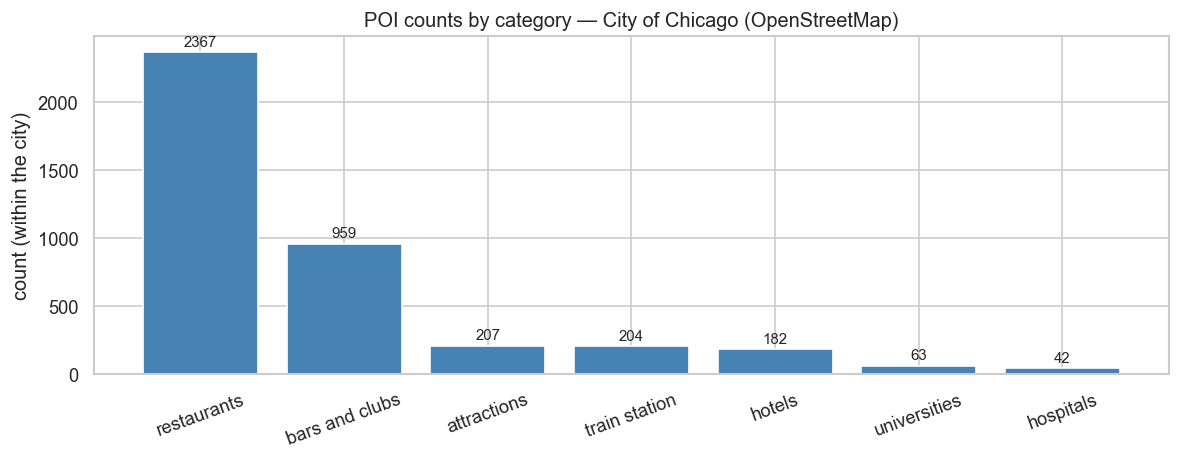

In [4]:
totals = poi_ca[COUNT_FEATURES].sum().sort_values(ascending=False)
labels = [c.replace("count_", "").replace("_", " ") for c in totals.index]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, totals.values, color="steelblue")
ax.bar_label(bars, fmt="%d", padding=2, fontsize=9)
ax.set_ylabel("count (within the city)")
ax.set_title("POI counts by category — City of Chicago (OpenStreetMap)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 2 — Feature distributions

How each POI feature is spread across the 77 community areas (heavy right-skew is expected — a few dense downtown cells dominate).

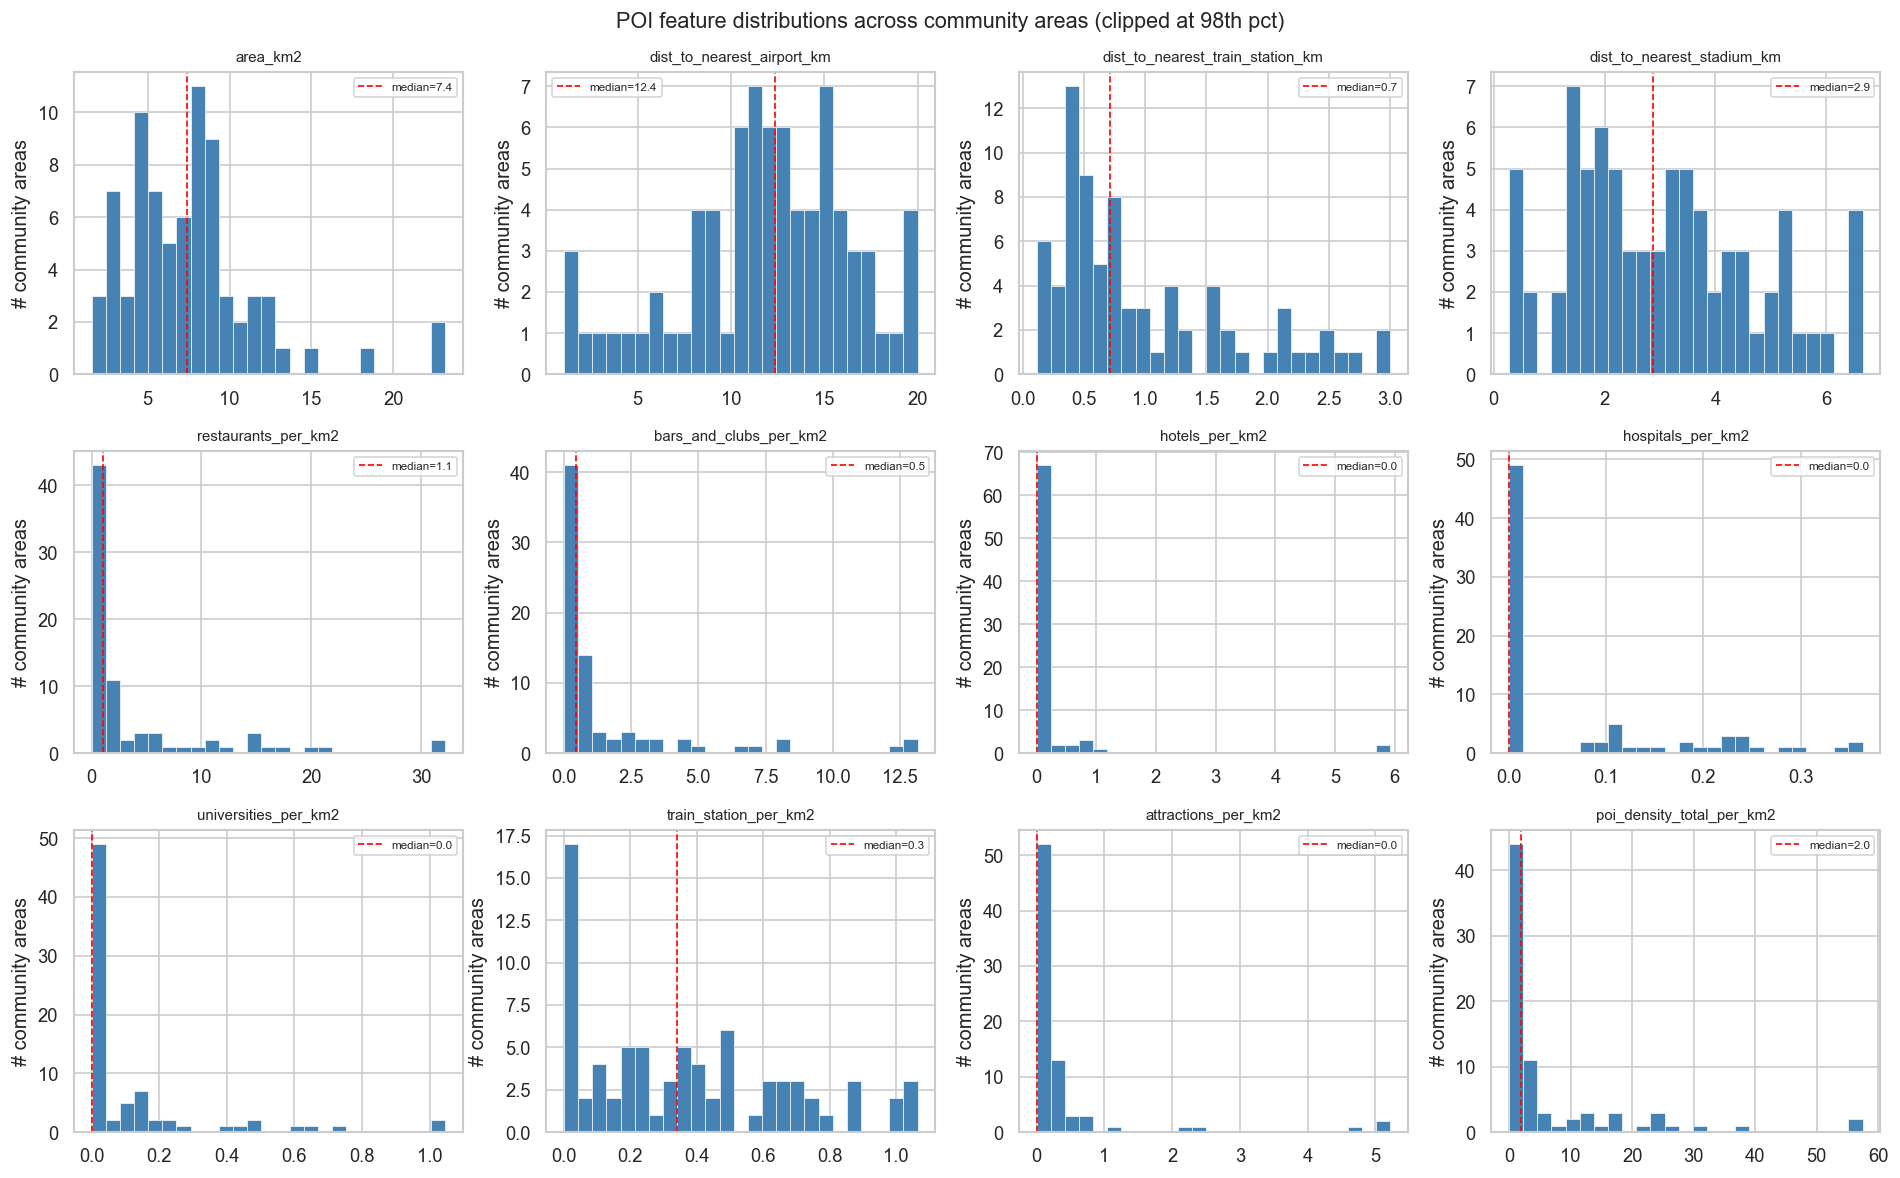

In [5]:
hist_feats = ["area_km2"] + DIST_FEATURES + DENS_FEATURES + [TOTAL]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, hist_feats):
    vals = poi_ca[col]
    clip = vals.quantile(0.98)
    ax.hist(vals.clip(upper=clip), bins=25, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(vals.median(), color="red", ls="--", lw=1, label=f"median={vals.median():.1f}")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("# community areas")
    ax.legend(fontsize=7)
for ax in axes.flat[len(hist_feats):]:
    ax.set_visible(False)
plt.suptitle("POI feature distributions across community areas (clipped at 98th pct)", fontsize=13)
plt.tight_layout(); plt.show()

## 3 — Choropleth maps (community areas)

Where each POI signal lives. Distances use a reversed map (bright = close); densities use
`plasma` (bright = dense), capped at the 97th percentile so a couple of extreme downtown
cells don't wash everything out.

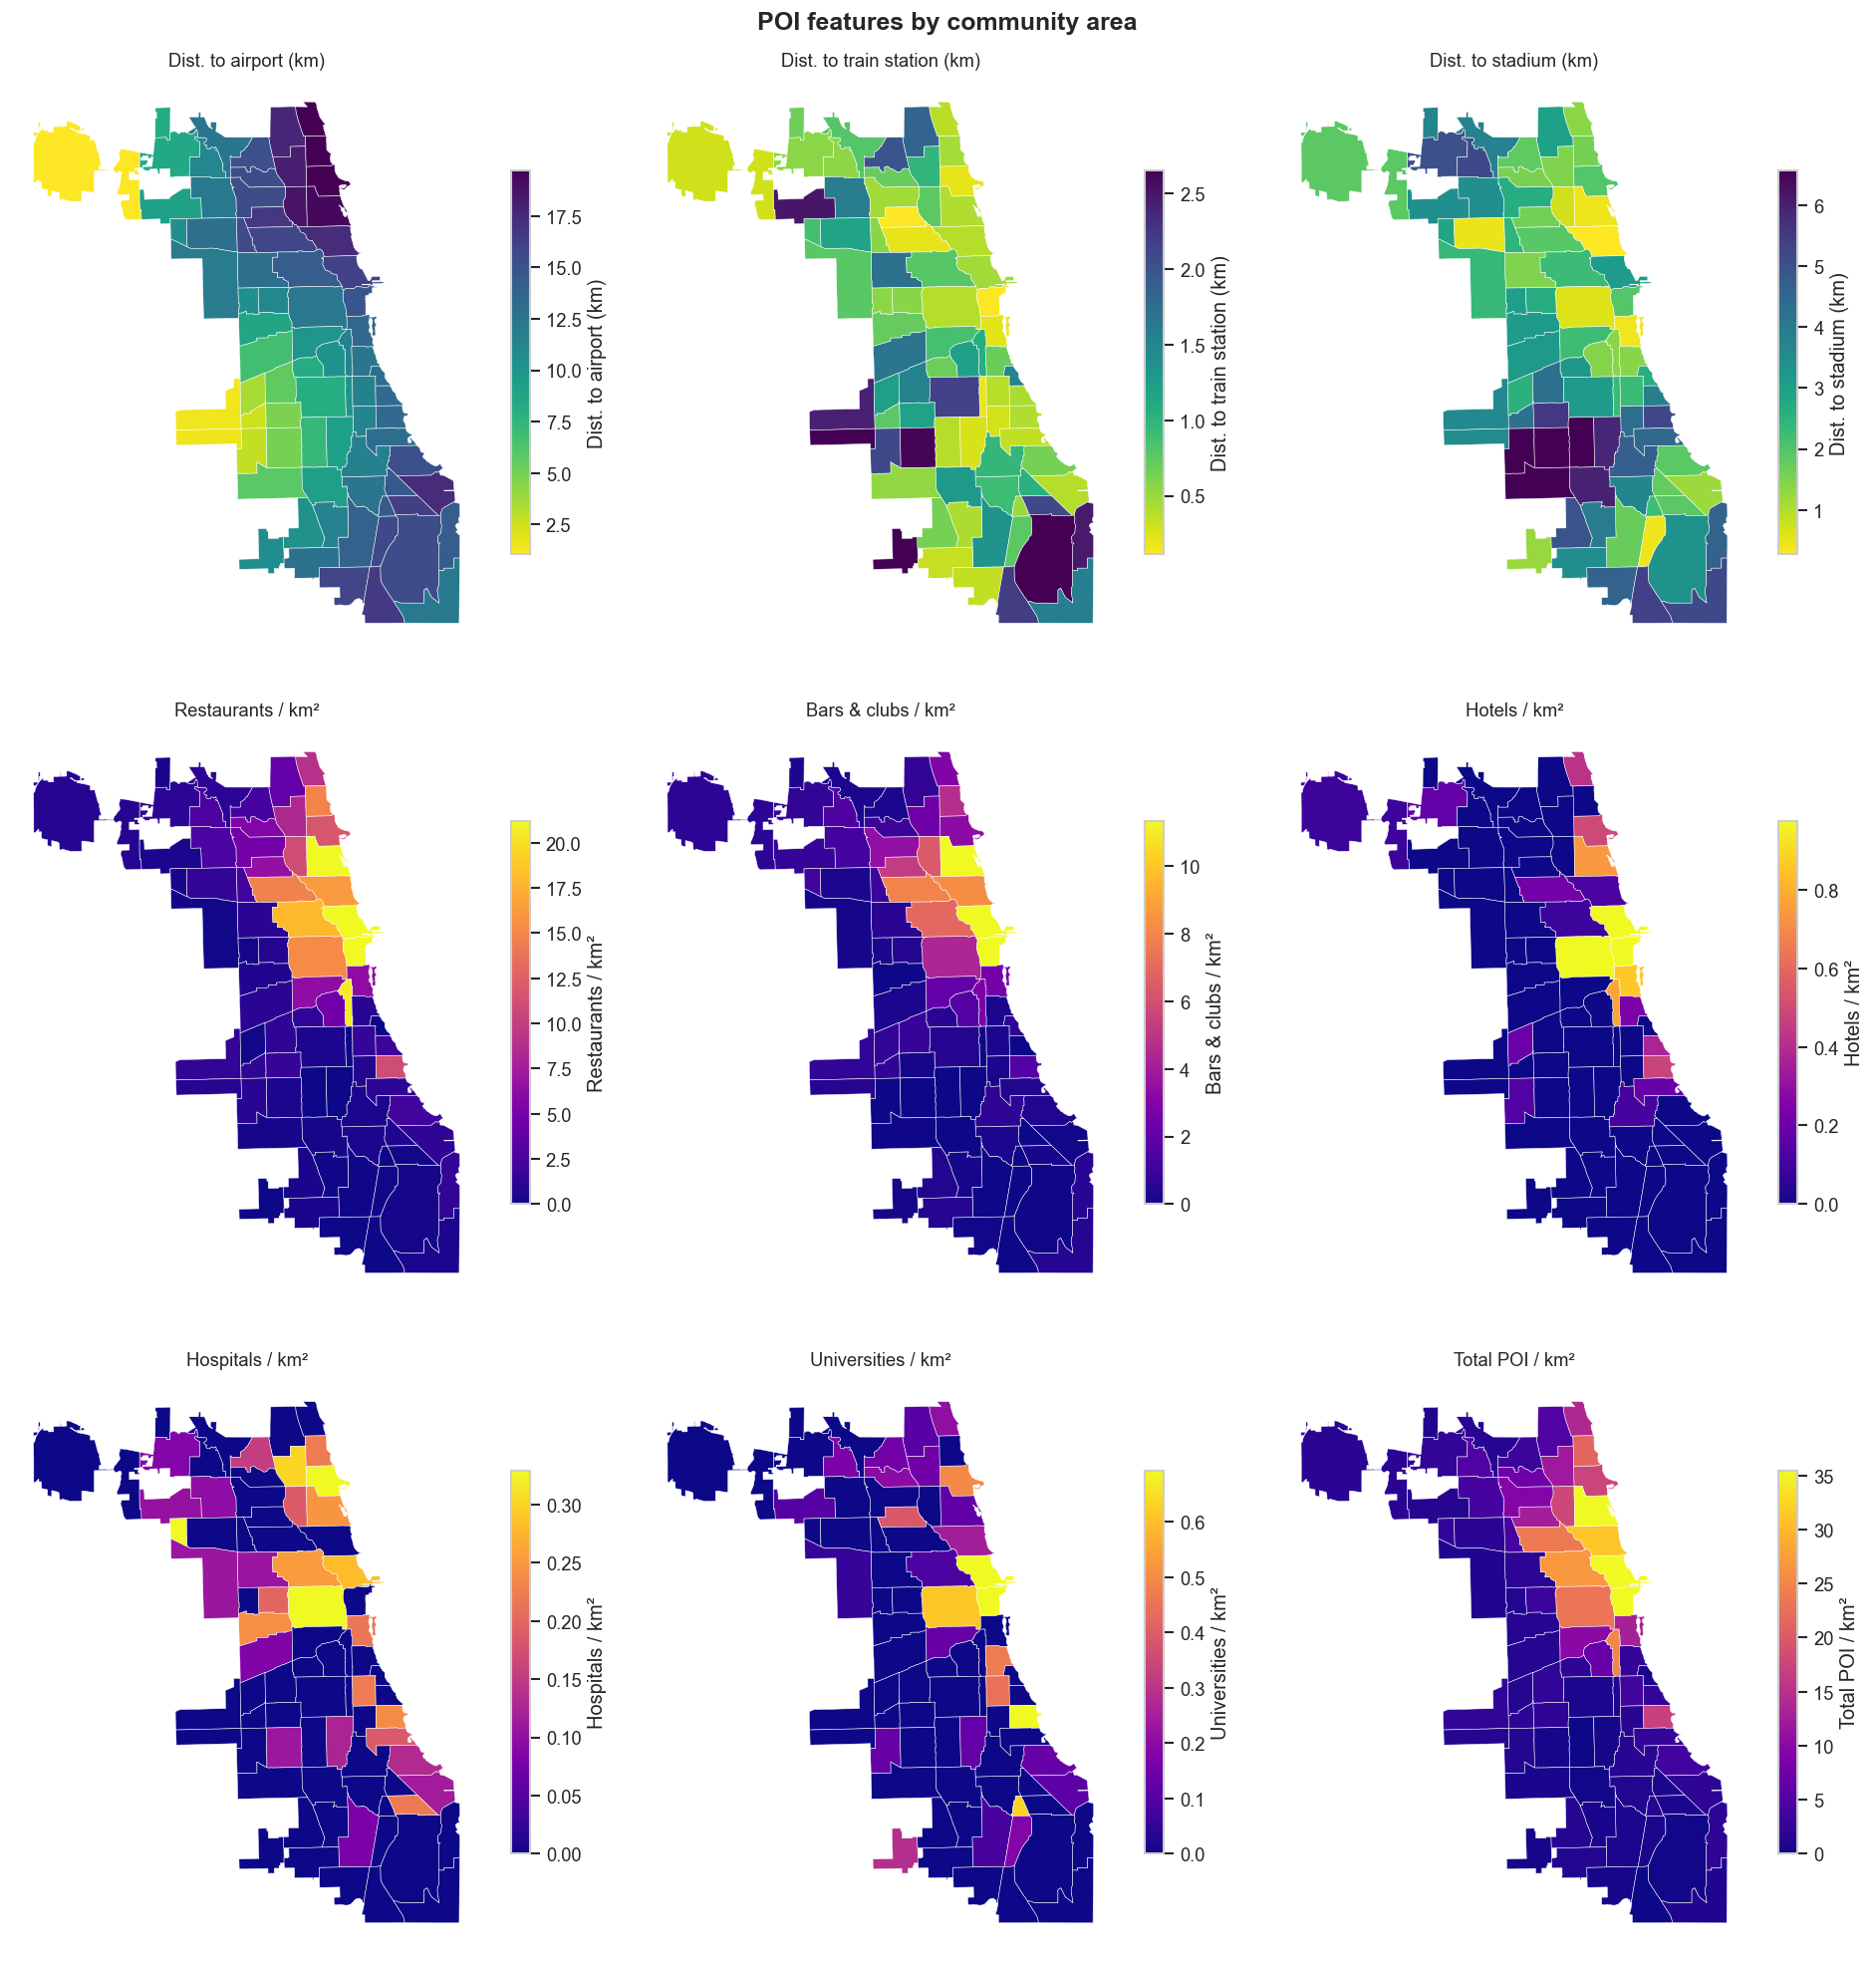

In [6]:
panels = [
    ("dist_to_nearest_airport_km",       "Dist. to airport (km)",      "viridis_r"),
    ("dist_to_nearest_train_station_km", "Dist. to train station (km)", "viridis_r"),
    ("dist_to_nearest_stadium_km",       "Dist. to stadium (km)",      "viridis_r"),
    ("restaurants_per_km2",  "Restaurants / km²", "plasma"),
    ("bars_and_clubs_per_km2","Bars & clubs / km²","plasma"),
    ("hotels_per_km2",       "Hotels / km²",      "plasma"),
    ("hospitals_per_km2",    "Hospitals / km²",   "plasma"),
    ("universities_per_km2", "Universities / km²","plasma"),
    ("poi_density_total_per_km2", "Total POI / km²","plasma"),
]
fig, axes = plt.subplots(3, 3, figsize=(16, 17))
for ax, (col, title, cmap) in zip(axes.flat, panels):
    vmax = ca[col].quantile(0.97)
    ca.plot(column=col, cmap=cmap, vmax=vmax, legend=True,
            legend_kwds={"label": title, "shrink": 0.6},
            edgecolor="white", linewidth=0.3, ax=ax)
    ax.set_title(title, fontsize=11); ax.set_axis_off()
plt.suptitle("POI features by community area", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

## 4 — H3 maps & resolution comparison

The same signal at two hexagon sizes (low = res 6, medium = res 7). Finer cells localise
the hotspots more sharply — directly relevant to the "varying hexagon diameter" question.

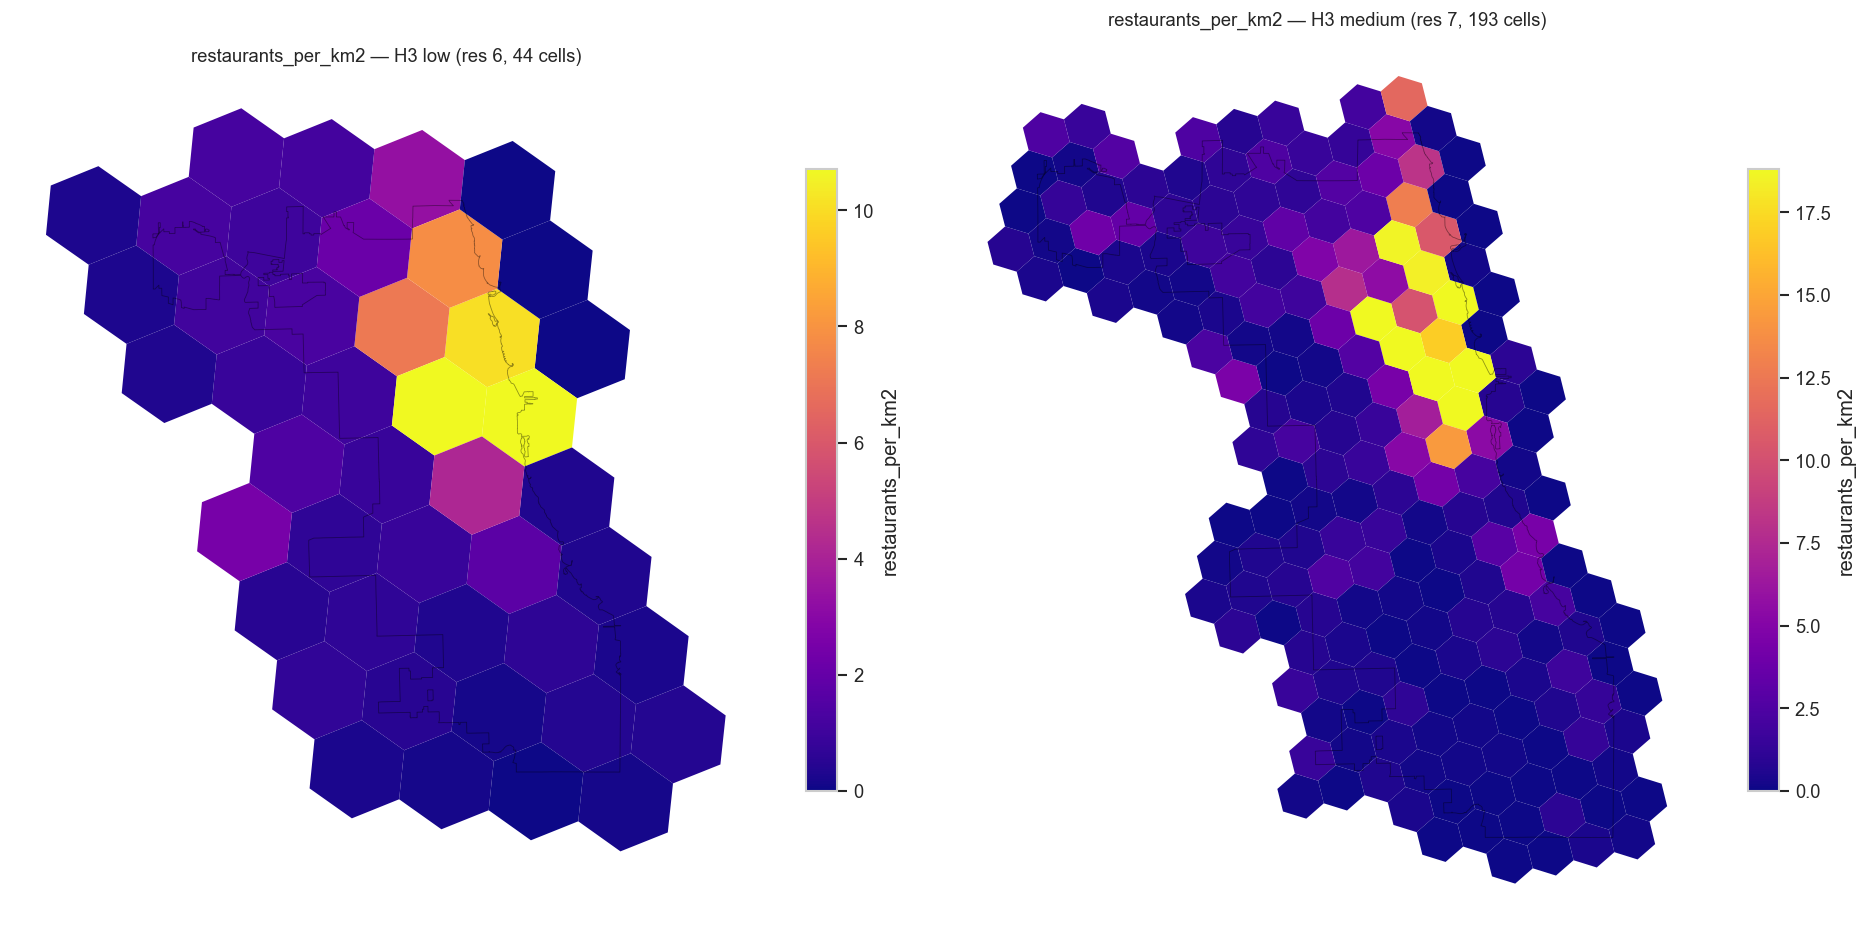

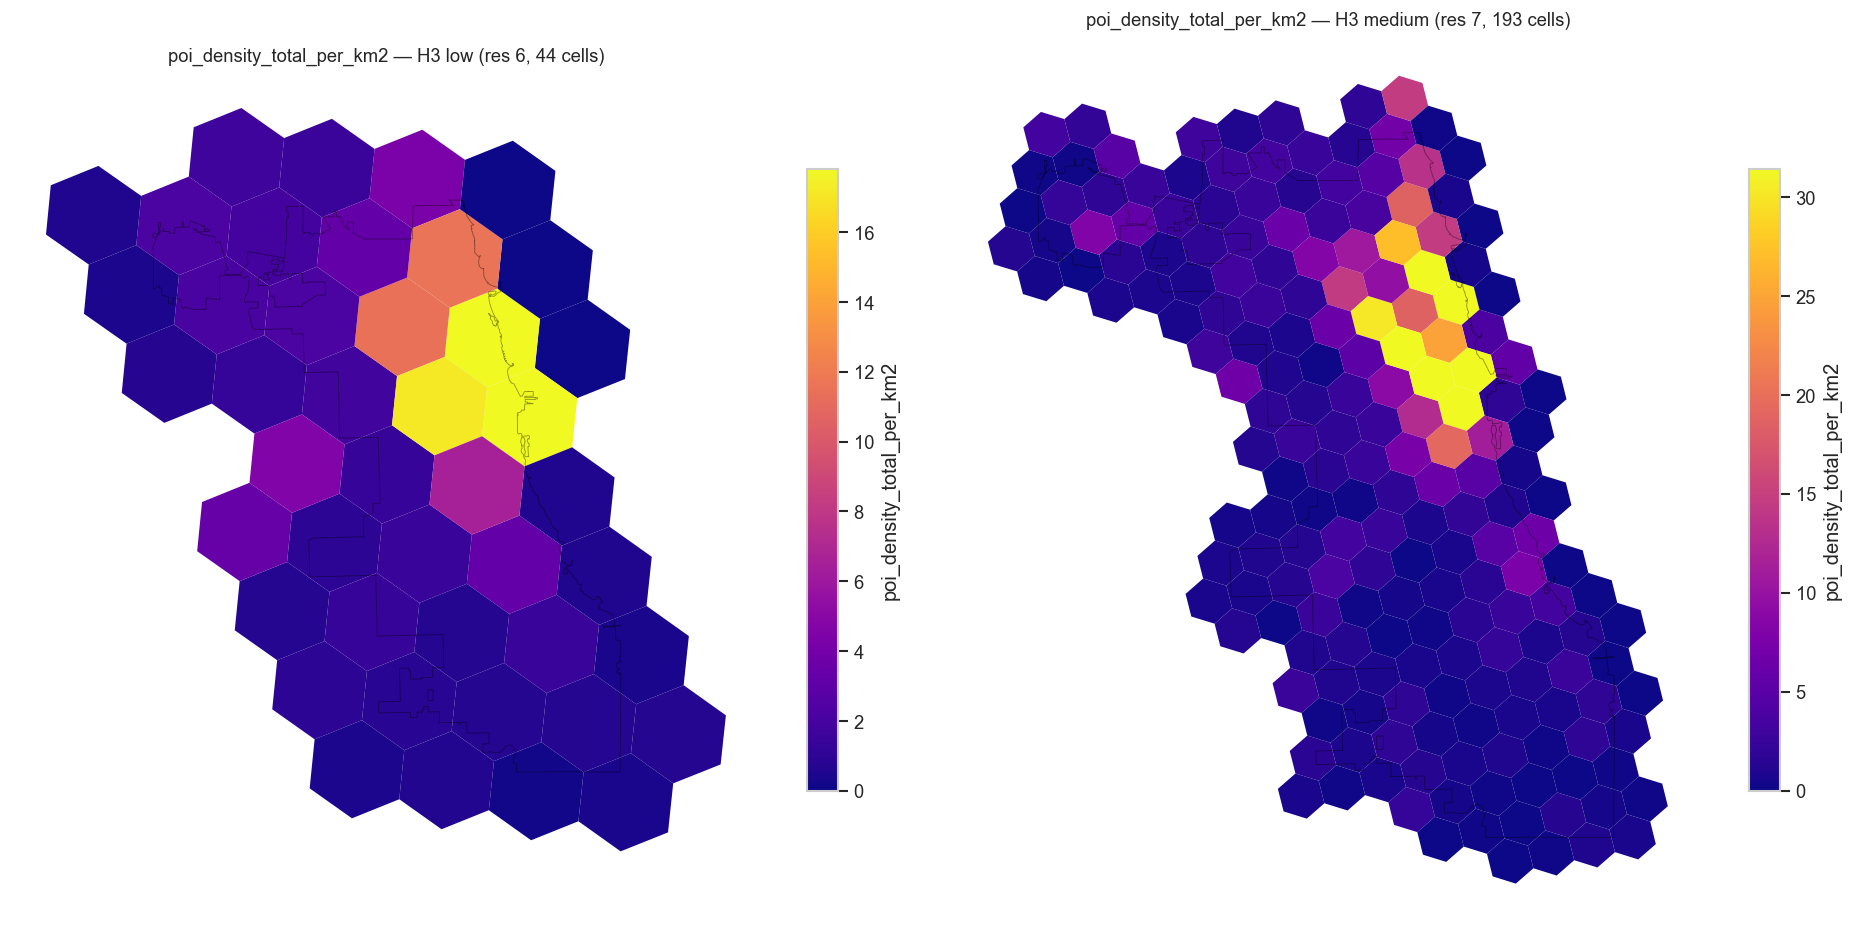

In [7]:
def hex_gdf(res_name):
    sub = poi_h3[poi_h3["resolution"] == res_name].copy()
    sub["geometry"] = [Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(c)])
                       for c in sub["h3_cell"]]
    return gpd.GeoDataFrame(sub, geometry="geometry", crs=4326)

for feature, cmap in [("restaurants_per_km2", "plasma"), ("poi_density_total_per_km2", "plasma")]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 9))
    for ax, res in zip(axes, ["low", "medium"]):
        g = hex_gdf(res)
        vmax = g[feature].quantile(0.97)
        CITY.plot(ax=ax, color="black", linewidth=0.5, alpha=0.4)
        g.plot(column=feature, cmap=cmap, vmax=vmax, legend=True,
               legend_kwds={"label": feature, "shrink": 0.6}, edgecolor="none", ax=ax)
        res_lvl = {"low": 6, "medium": 7}[res]
        ax.set_title(f"{feature} — H3 {res} (res {res_lvl}, {len(g)} cells)", fontsize=11)
        ax.set_axis_off()
    plt.tight_layout(); plt.show()

## 5 — Correlations among POI features

Which POI signals move together. Restaurants, bars, hotels and attractions co-vary (they all peak downtown); airport distance is largely independent.

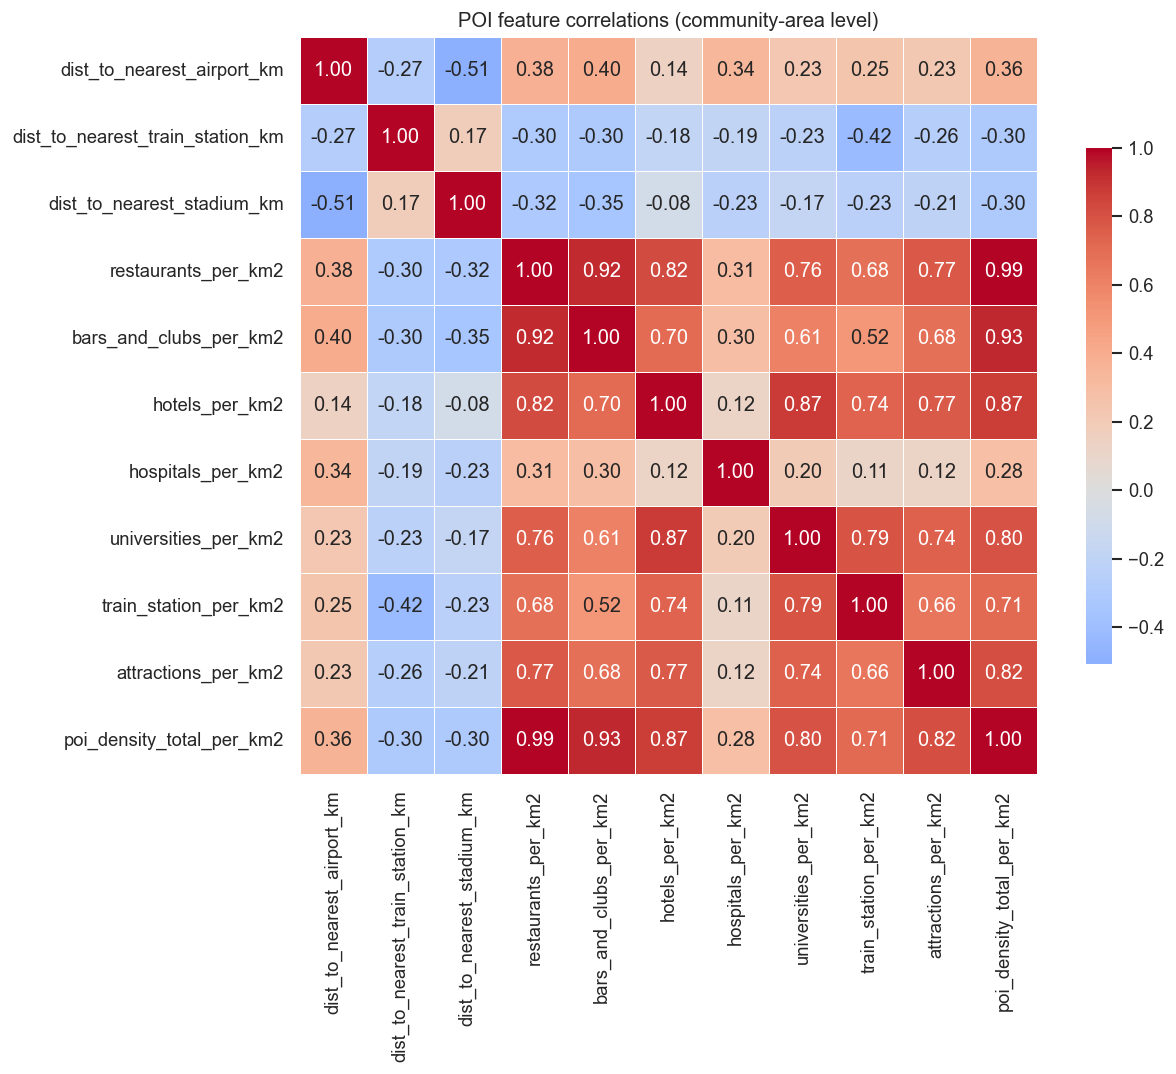

In [8]:
corr_cols = DIST_FEATURES + DENS_FEATURES + [TOTAL]
corr = poi_ca[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("POI feature correlations (community-area level)", fontsize=12)
plt.tight_layout(); plt.show()

## 6 — Top community areas by feature

The leading areas for a few key signals (community-area names).

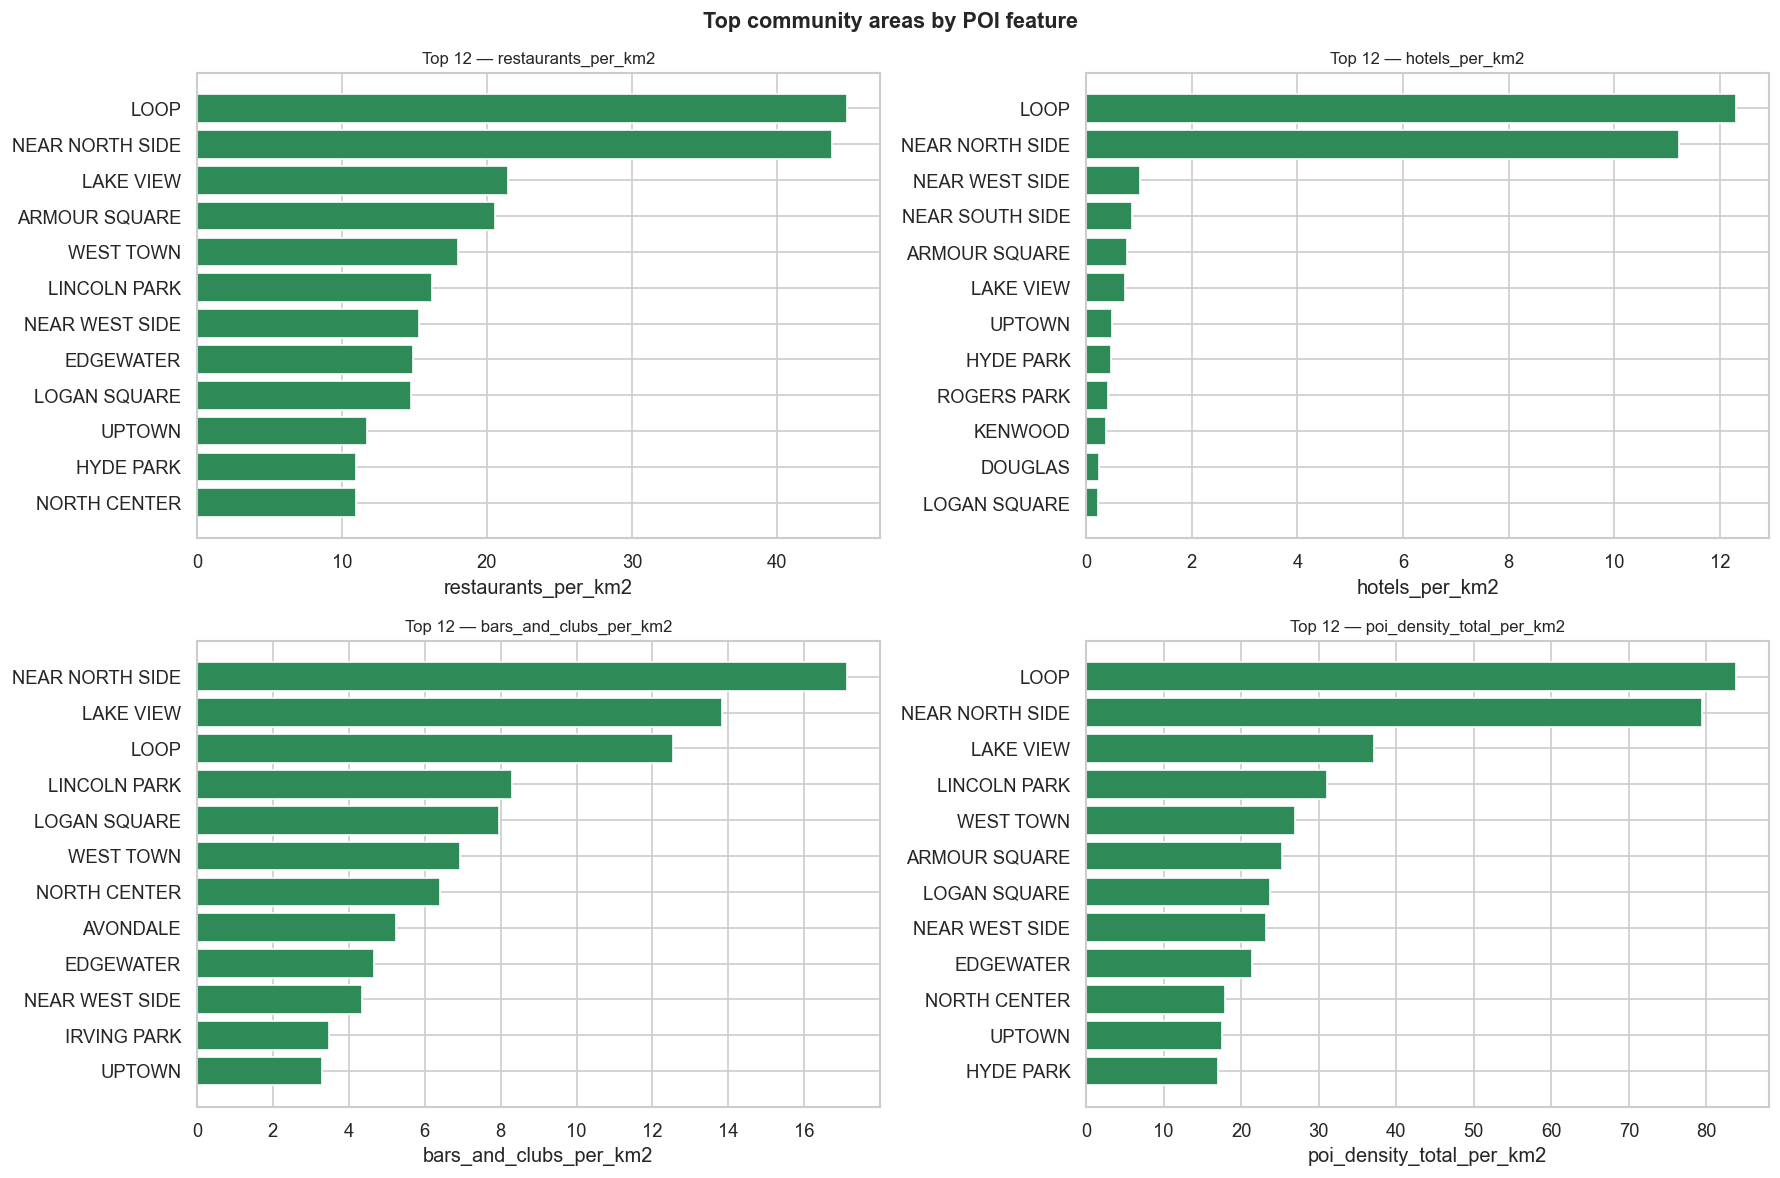

In [9]:
top_feats = ["restaurants_per_km2", "hotels_per_km2", "bars_and_clubs_per_km2", "poi_density_total_per_km2"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.flat, top_feats):
    top = ca.nlargest(12, col)[["community", col]].iloc[::-1]
    ax.barh(top["community"], top[col], color="seagreen")
    ax.set_title(f"Top 12 — {col}", fontsize=10)
    ax.set_xlabel(col)
plt.suptitle("Top community areas by POI feature", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 7 — POI vs taxi demand

Do the POI features actually relate to where taxis are busy? We join total 2025 trips per
community area (from the 24h demand dataset) to the POI features and check the correlations.
Strong positive correlations would support using POI as explanatory / predictive context.

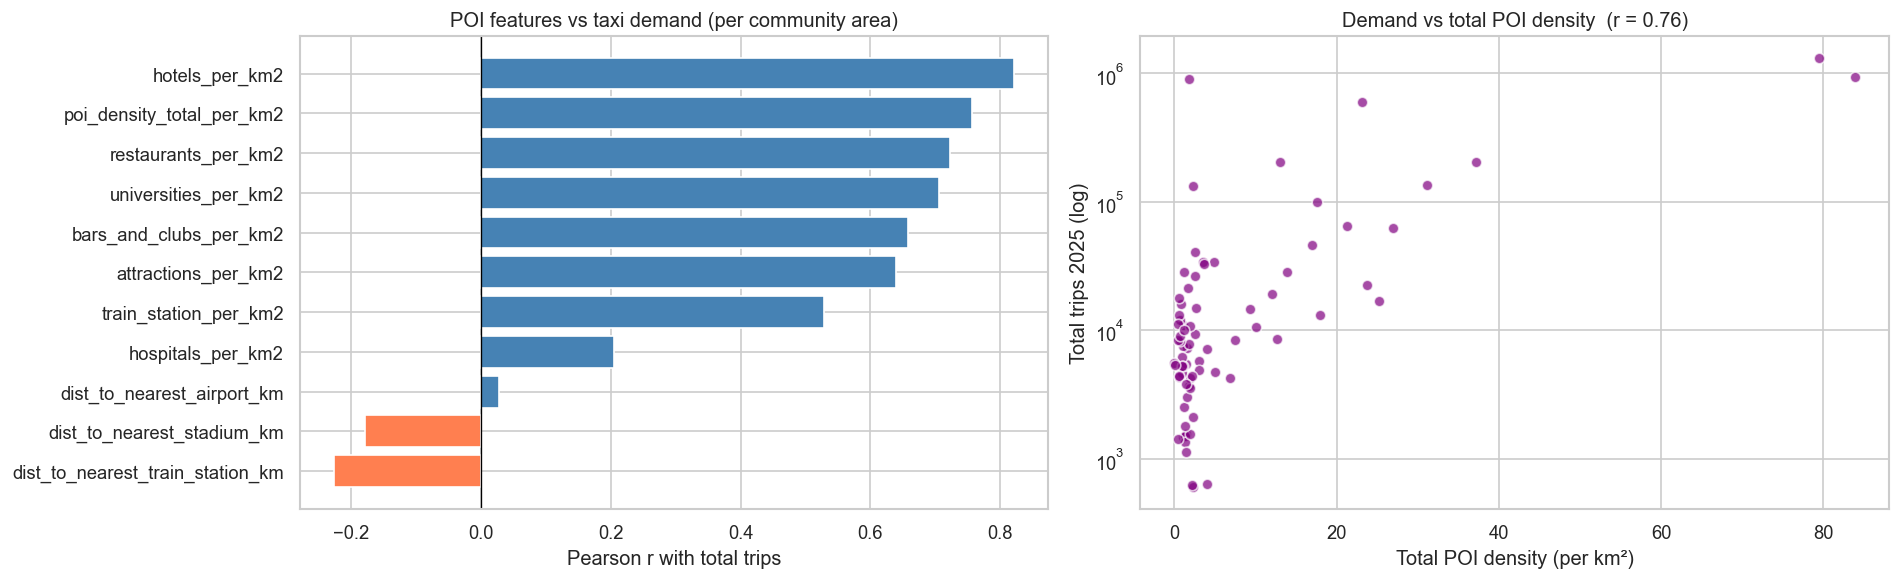

dist_to_nearest_train_station_km   -0.227
dist_to_nearest_stadium_km         -0.179
dist_to_nearest_airport_km          0.028
hospitals_per_km2                   0.204
train_station_per_km2               0.528
attractions_per_km2                 0.640
bars_and_clubs_per_km2              0.659
universities_per_km2                0.706
restaurants_per_km2                 0.724
poi_density_total_per_km2           0.756
hotels_per_km2                      0.822


In [10]:
demand = pd.read_parquet("data/aggregated/community_area/demand_ca_24h.parquet")
total_demand = (demand.groupby("pickup_community_area")["trip_count"].sum()
                      .rename("total_trips").reset_index())
m = poi_ca.merge(total_demand, left_on="community_area", right_on="pickup_community_area")

feat_cols = DIST_FEATURES + DENS_FEATURES + [TOTAL]
corrs = (m[feat_cols + ["total_trips"]].corr()["total_trips"].drop("total_trips")
           .sort_values())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# (a) correlation of each POI feature with total demand
colors = ["coral" if v < 0 else "steelblue" for v in corrs.values]
axes[0].barh(corrs.index, corrs.values, color=colors)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("Pearson r with total trips")
axes[0].set_title("POI features vs taxi demand (per community area)")

# (b) scatter: total POI density vs demand
axes[1].scatter(m[TOTAL], m["total_trips"], s=40, alpha=0.7, color="purple", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_xlabel("Total POI density (per km²)")
axes[1].set_ylabel("Total trips 2025 (log)")
axes[1].set_title(f"Demand vs total POI density  (r = {m[TOTAL].corr(m['total_trips']):.2f})")
plt.tight_layout(); plt.show()

print(corrs.round(3).to_string())